# 1D CNN — Learning
Load csv into a sliding window of OHLCV bars using a 1D convolutional neural network (PyTorch).

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # macOS: prevents libiomp/libomp conflict

from datetime import date

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

print(f"PyTorch {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.2.2 | device: cpu


## 2. Config

In [ ]:
# --- Data ---
SYMBOL      = "TSLA"
TIMEFRAME   = "1Min"
START_DATE  = "2017-01-01"
END_DATE    = str(date.today())
DATA_DIR    = os.path.join("..", "..", "data")   # project root /data
API_BASE    = "http://localhost:8000"
FETCH_DATA  = False   # set True to re-pull from Alpaca; leave False for Run All
MAX_BARS    = 200000    # int to limit rows loaded (e.g. 50_000), None for all

# --- Windowing ---
WINDOW_SIZE = 64      # bars per input window

# --- Autoencoder ---
LATENT_DIM  = 32
BATCH_SIZE  = 256
EPOCHS      = 10 # 30
LR          = 1e-3
TEST_SPLIT  = 0.2

# --- Clustering ---
N_CLUSTERS  = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Symbol={SYMBOL}  Timeframe={TIMEFRAME}  {START_DATE} → {END_DATE}")
print("Using device:", DEVICE)

Symbol=TSLA  Timeframe=1Min  2017-01-01 → 2026-06-10
Using device: cpu


## 3. Fetch Data from Alpaca API
Calls the local `alpaca_api` FastAPI service (must be running: `uv run main.py`).
Fetches TSLA 1-minute bars and saves to both DB and CSV.

In [3]:
if FETCH_DATA:
    params = {
        "symbols": SYMBOL,
        "timeframe": TIMEFRAME,
        "start": START_DATE,
        "end": END_DATE,
        "save_to": "db,csv",
    }
    with httpx.Client(timeout=None) as client:
        r = client.get(f"{API_BASE}/bars", params=params)
        r.raise_for_status()
        result = r.json()
    bars = result.get("data", {}).get("bars", {}).get(SYMBOL, [])
    print(f"Fetched {len(bars)} bars for {SYMBOL}")
    print("Saved:", result.get("saved"))
else:
    print("FETCH_DATA=False — skipping. Set True in Config to re-pull.")

FETCH_DATA=False — skipping. Set True in Config to re-pull.


## 4. Load Data

In [ ]:
csv_path = os.path.join(DATA_DIR, SYMBOL, f"{TIMEFRAME}.csv")
df = pd.read_csv(csv_path, parse_dates=["timestamp"], nrows=MAX_BARS)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Loaded {len(df):,} bars from {df['timestamp'].min()} to {df['timestamp'].max()}")
max_bars_display = 'all' if MAX_BARS is None else f'{MAX_BARS:,}'
print(f"(MAX_BARS={max_bars_display})")
df[["timestamp", "open", "high", "low", "close", "volume"]].tail()

Check for:

Duplicate timestamps
Missing timestamps (gaps)
NaNs
Infinite values
Bad OHLC relationships (high < low, etc.)

Typical checks:

In [5]:
df = df.drop_duplicates(subset=["timestamp"])
df = df.dropna()

df.isnull().sum()
df.duplicated(subset=["timestamp"]).sum()
df[["timestamp", "open", "high", "low", "close", "volume"]].tail()

,timestamp,open,high,low,close,volume
199995,2022-10-11 19:46:00+00:00,216.150,216.160,215.860,215.935,4633
199996,2022-10-11 19:47:00+00:00,215.850,216.310,215.850,216.220,2945
199997,2022-10-11 19:48:00+00:00,216.095,216.530,216.095,216.500,6817
199998,2022-10-11 19:49:00+00:00,216.530,216.765,216.450,216.565,6706
199999,2022-10-11 19:50:00+00:00,216.610,216.610,215.740,216.190,8256


## 5. Verify Time Continuity
A CNN assumes a consistent sequence.

Look for:

missing bars
duplicate bars
irregular spacing

If you're using 1-minute candles, every row should be exactly 1 minutes apart.

In [6]:
delta = df["timestamp"].diff()
dt = pd.to_timedelta(delta).dt.total_seconds()
print("Average time delta (seconds):", dt.mean())
print("Time delta distribution (seconds):")
print(dt.describe())

Average time delta (seconds): 348.3077415387077
Time delta distribution (seconds):
count    199999.000000
mean        348.307742
std        6647.136935
min          60.000000
25%          60.000000
50%          60.000000
75%          60.000000
max      329400.000000
Name: timestamp, dtype: float64


## 6. Add Features

In [7]:
# EMAs
df["ema_9"] = df["close"].ewm(span=9, adjust=False).mean()
df["ema_21"] = df["close"].ewm(span=21, adjust=False).mean()
df["ema_50"] = df["close"].ewm(span=50, adjust=False).mean()

# MACD components
df["macd_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["macd_26"] = df["close"].ewm(span=26, adjust=False).mean()

# MACD line
df["macd"] = df["macd_12"] - df["macd_26"]

# MACD signal line (9 EMA of MACD)
df["macd_9"] = df["macd"].ewm(span=9, adjust=False).mean()

# MACD histogram (optional but commonly used)
df["macd_hist"] = df["macd"] - df["macd_9"]

# Candle details
df["body"] = df["close"] - df["open"]
df["upper_wick"] = df["high"] - df[["open", "close"]].max(axis=1)
df["lower_wick"] = df[["open", "close"]].min(axis=1) - df["low"]



# other
df["return"] = df["close"].pct_change()
df["vol_return"] = df["volume"].pct_change()
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["volume_ratio"] = (
    df["volume"] /
    df["volume"].rolling(20).mean()
)

# display sample of new features
# df[["timestamp", "close", "ema_9", "ema_21", "ema_50", "macd", "macd_9", "macd_hist", "body", "upper_wick", "lower_wick", "return", "vol_return", "log_return", "volume_ratio"]].tail()

df[df["body"] != 0][
    [
        "timestamp",
        "close",
        "ema_9",
        "ema_21",
        "ema_50",
        "macd",
        "macd_9",
        "macd_hist",
        "body",
        "upper_wick",
        "lower_wick",
        "return",
        "vol_return",
        "log_return",
        "volume_ratio",
    ]
].tail()

,timestamp,close,ema_9,ema_21,ema_50,macd,macd_9,macd_hist,body,upper_wick,lower_wick,return,vol_return,log_return,volume_ratio
199995,2022-10-11 19:46:00+00:00,215.935,216.062763,216.036912,216.292738,0.021867,0.028917,-0.007050,-0.215,0.01,0.075,-0.000579,0.363449,-0.000579,1.503928
199996,2022-10-11 19:47:00+00:00,216.220,216.094211,216.053556,216.289885,0.032908,0.029715,0.003193,0.370,0.09,0.000,0.001320,-0.364343,0.001319,0.937092
199997,2022-10-11 19:48:00+00:00,216.500,216.175368,216.094142,216.298125,0.063520,0.036476,0.027044,0.405,0.03,0.000,0.001295,1.314771,0.001294,2.029352
199998,2022-10-11 19:49:00+00:00,216.565,216.253295,216.136947,216.308591,0.091964,0.047574,0.044391,0.035,0.20,0.080,0.000300,-0.016283,0.000300,1.941461
199999,2022-10-11 19:50:00+00:00,216.190,216.240636,216.141770,216.303940,0.083287,0.054716,0.028571,-0.420,0.00,0.450,-0.001732,0.231136,-0.001733,2.238794


## 6. Remove Initial NaNs

Feature engineering creates NaNs.

In [8]:
df = df.dropna().reset_index(drop=True)

## 7. Scale Features

This is critical.

CNNs train poorly on:

close = 45000
volume = 10000000
return = 0.001

all mixed together.

StandardScaler

Most common:

In [9]:
from sklearn.preprocessing import StandardScaler, RobustScaler

feature_cols = ["close", "ema_9", "ema_21", "ema_50", "macd", "macd_9", "macd_hist", "body", "upper_wick", "lower_wick", "return", "vol_return", "log_return", "volume_ratio"]
# scaler = StandardScaler()
# df[feature_cols] = scaler.fit_transform(df[feature_cols])

scaler = RobustScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
# Often better for financial data due to outliers

df[["timestamp", "open", "high", "low", "close", "volume", "ema_9", "ema_21", "ema_50", "macd", "macd_9", "macd_hist", "body", "upper_wick", "lower_wick", "return", "vol_return", "log_return", "volume_ratio"]].tail()

,timestamp,open,high,low,close,volume,ema_9,ema_21,ema_50,macd,macd_9,macd_hist,body,upper_wick,lower_wick,return,vol_return,log_return,volume_ratio
199976,2022-10-11 19:46:00+00:00,216.150,216.160,215.860,-0.364362,4633,-0.363475,-0.364902,-0.360763,0.043388,0.061946,-0.036350,-0.895833,0.25,1.875,-0.373619,0.354448,-0.373725,0.871212
199977,2022-10-11 19:47:00+00:00,215.850,216.310,215.850,-0.360664,2945,-0.363066,-0.364686,-0.360800,0.068604,0.063869,0.039759,1.541667,2.25,0.000,0.852344,-0.345628,0.851777,0.117097
199978,2022-10-11 19:48:00+00:00,216.095,216.530,216.095,-0.357032,6817,-0.362012,-0.364159,-0.360693,0.138517,0.080151,0.216980,1.687500,0.75,0.000,0.836287,1.269541,0.835741,1.570234
199979,2022-10-11 19:49:00+00:00,216.530,216.765,216.450,-0.356188,6706,-0.361000,-0.363602,-0.360557,0.203482,0.106878,0.345877,0.145833,5.00,2.000,0.193887,-0.010823,0.193857,1.453304
199980,2022-10-11 19:50:00+00:00,216.610,216.610,215.740,-0.361053,8256,-0.361164,-0.363540,-0.360618,0.183665,0.124081,0.228330,-1.750000,0.00,11.250,-1.118243,0.227174,-1.119206,1.848874


## 8. Create Fixed-Length Windows

A CNN does not ingest an entire dataframe.

It ingests samples.

In [10]:
n_features = len(feature_cols)
print(f"Features ({n_features}):", feature_cols)
print("Data shape:", df[feature_cols].shape)

data = df[feature_cols].to_numpy(dtype=np.float32)

X_raw = np.lib.stride_tricks.sliding_window_view(
    data,
    window_shape=WINDOW_SIZE,
    axis=0
).transpose(0, 2, 1)   # → (N, WINDOW_SIZE, n_features)

print("X_raw shape:", X_raw.shape)

Features (14): ['close', 'ema_9', 'ema_21', 'ema_50', 'macd', 'macd_9', 'macd_hist', 'body', 'upper_wick', 'lower_wick', 'return', 'vol_return', 'log_return', 'volume_ratio']
Data shape: (199981, 14)
X_raw shape: (199918, 64, 14)


## 11. Filter Gap Windows
A window that spans an overnight or weekend gap mixes pre-gap and post-gap bars — the CNN would learn noise, not patterns. Any window whose 64-bar span crosses a gap > 5 minutes is dropped.

In [11]:
diffs_sec = df["timestamp"].diff().dt.total_seconds().fillna(0).to_numpy()
gap_positions = np.where(diffs_sec > 300)[0]   # > 5 min between consecutive bars

valid_mask = np.ones(len(X_raw), dtype=bool)
for gp in gap_positions:
    lo = max(0, gp - WINDOW_SIZE + 1)
    hi = min(len(X_raw), gp + 1)
    valid_mask[lo:hi] = False

X_clean = X_raw[valid_mask]
print(f"Gap positions: {len(gap_positions)}")
print(f"Removed {(~valid_mask).sum():,} gap-spanning windows")
print(f"Clean windows: {X_clean.shape[0]:,}  shape: {X_clean.shape}")

Gap positions: 1234
Removed 43,137 gap-spanning windows
Clean windows: 156,781  shape: (156781, 64, 14)


## 9. Visualise Windows as Greyscale Tiles

Before training, it's worth seeing what the windowed data actually *looks like*.
Each of the 156,781 clean windows is a 64-bar × 14-feature matrix of scaled
floats. Rendering them as greyscale images (bright = high value, dark = low)
lets us visually inspect the dataset for structure, gaps, outliers, and feature
behaviour at a scale no table or line-chart can match.

Three views are provided — all use the same global [0 → 255] normalisation so
brightness is directly comparable across windows and across views:

| View | What you see | Best for |
|------|-------------|----------|
| A — Contact sheet | Each window at full 64×14 px resolution, tiled in a grid | Inspecting individual window texture and feature patterns |
| B — Heatmap strip | Each window flattened to one row, all windows stacked vertically | Spotting dataset-wide trends, session rhythms, and drift over time |
| C — Thumbnail grid | Each window compressed to 10×10 px, tiled densely | Getting a high-level overview of brightness/contrast across the whole sample |

Adjust `N_SAMPLE` in the setup cell below to control how many windows are rendered.

In [ ]:
from PIL import Image

N_SAMPLE = 2_000   # number of windows to render — change freely

sample = X_clean[:N_SAMPLE]                            # (N_SAMPLE, 64, 14)

# Percentile clipping: use p2/p98 instead of absolute min/max so that
# outlier spikes don't compress the bulk of values into a dark narrow band.
lo, hi         = np.percentile(sample, 2), np.percentile(sample, 98)
sample_clipped = np.clip(sample, lo, hi)
sample_u8      = ((sample_clipped - lo) / (hi - lo) * 255).astype(np.uint8)
# sample_u8: (N_SAMPLE, 64, 14) uint8 — values 0-255, outliers clamped

print(f"Rendering {N_SAMPLE:,} windows  |  p2={lo:.3f}  p98={hi:.3f}  →  [0, 255]")

### View A — Contact Sheet (natural resolution: 64 × 14 px per window)

Each window is rendered at its natural shape: **64 pixels tall** (one pixel row
per bar) and **14 pixels wide** (one pixel column per feature). No information
is lost — every pixel represents exactly one bar/feature value.

Windows are tiled left-to-right across the canvas, wrapping into new rows, like
a filmstrip or contact sheet. A 1-pixel gap separates each block so individual
windows are distinguishable.

**What to look for:**
- **Vertical banding** within a block: a feature column that is consistently
  bright or dark across all 64 bars — likely an EMA or price feature at an extreme.
- **Horizontal banding** within a block: a single bar (row) that stands out
  across all 14 features simultaneously — could be a volume spike or large candle.
- **Blocks that look uniform / flat**: windows where all features stayed near the
  median (scaled to mid-grey ~128). Common during low-volatility periods.
- **Blocks that look noisy**: highly varied pixel values — active, volatile conditions.
- **Repeating texture patterns** across many blocks: candidate patterns the
  autoencoder should learn to encode and reconstruct.

In [ ]:
SCALE       = 4          # pixel-repeat scale factor — 1 = natural (64×14 px), 4 = 256×56 px
GRID_COLS_A = 50
GAP_PX      = 1          # 1-px separator between blocks for readability
BLOCK_H     = 64 * SCALE
BLOCK_W     = 14 * SCALE

n_rows_a = (N_SAMPLE + GRID_COLS_A - 1) // GRID_COLS_A
cell_h   = BLOCK_H + GAP_PX
cell_w   = BLOCK_W + GAP_PX
canvas_a = np.full((n_rows_a * cell_h, GRID_COLS_A * cell_w), 64, dtype=np.uint8)

for i, block in enumerate(sample_u8):
    r, c   = divmod(i, GRID_COLS_A)
    scaled = np.repeat(np.repeat(block, SCALE, axis=0), SCALE, axis=1)  # (64*S, 14*S)
    canvas_a[r*cell_h : r*cell_h + BLOCK_H,
             c*cell_w : c*cell_w + BLOCK_W] = scaled

fig, ax = plt.subplots(figsize=(20, max(4, n_rows_a * cell_h / 50)))
ax.imshow(canvas_a, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax.axis('off')
ax.set_title(
    f'View A — Contact Sheet  |  {N_SAMPLE:,} windows  |  '
    f'{BLOCK_H}×{BLOCK_W} px each (scale={SCALE}×)  |  {GRID_COLS_A} per row',
    fontsize=10
)
plt.tight_layout()
plt.show()

### View B — Heatmap Strip (one row per window, 896 px wide)

Each 64×14 window is **flattened into a single row of 896 values** (64 bars ×
14 features, concatenated left-to-right). All `N_SAMPLE` rows are stacked
vertically to form a 2D heatmap where:

- **X-axis (horizontal):** position within a window. The 896 columns cycle
  through all 14 features for bar 0, then all 14 for bar 1, and so on.
  Red dividers mark the boundary between each feature channel.
- **Y-axis (vertical):** window index — top = earliest window, bottom = latest.

**What to look for:**
- **Horizontal bands of consistent colour**: a feature at a sustained extreme
  across many consecutive windows — e.g. a trending period where EMA values
  are persistently bright or dark.
- **Vertical bright/dark stripes**: a feature that is consistently extreme
  *within* its column across all windows — `volume_ratio` often stands out here.
- **Gradual brightness drift** top → bottom: the dataset evolving over time —
  price levels, volatility regimes, or micro-structure changes.
- **Sharp horizontal edges**: abrupt regime changes (earnings, macro events)
  where the data character shifts suddenly.
- **Uniform mid-grey regions**: quiet, low-information periods.

In [ ]:
strip = sample_u8.reshape(N_SAMPLE, -1)    # (N_SAMPLE, 896)

fig, ax = plt.subplots(figsize=(20, max(4, N_SAMPLE / 80)))
img = ax.imshow(strip, cmap='gray', vmin=0, vmax=255,
                interpolation='nearest', aspect='auto')
plt.colorbar(img, ax=ax, fraction=0.01, pad=0.01, label='Scaled value (0 = low, 255 = high)')

# Mark feature-channel boundaries along the x-axis
n_feat = sample_u8.shape[2]   # 14
for f in range(n_feat):
    ax.axvline(x=f * WINDOW_SIZE, color='red', linewidth=0.3, alpha=0.5)
ax.set_xticks([f * WINDOW_SIZE + WINDOW_SIZE // 2 for f in range(n_feat)])
ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)

ax.set_xlabel('Feature channel  (each channel spans 64 bar positions)', fontsize=9)
ax.set_ylabel('Window index  (top = earliest)', fontsize=9)
ax.set_title(
    f'View B — Heatmap Strip  |  {N_SAMPLE:,} windows × '
    f'{strip.shape[1]} values  ({n_feat} features × {WINDOW_SIZE} bars)',
    fontsize=10
)
plt.tight_layout()
plt.show()

### View C — Thumbnail Grid (10 × 10 px per window)

Each 64×14 window is **downsampled to a 10×10 pixel thumbnail** using Lanczos
resampling — a high-quality filter that anti-aliases rather than simply dropping
pixels. The 100 resulting pixels capture the coarse spatial distribution of
values across the window (bright regions, dark regions, gradients) but not
fine detail.

Thumbnails are tiled left-to-right in rows of 100, forming a dense overview
of the full sample in a compact space.

**What to look for:**
- **Overall brightness distribution**: do most thumbnails cluster around
  mid-grey (balanced windows) or are many very bright/dark (trending or
  extreme market conditions)?
- **Clusters of similar-looking thumbnails**: groups of adjacent windows with
  the same gross texture — candidate pattern groups the autoencoder should
  discover. Randomness here is also informative.
- **Outlier blocks**: thumbnails that look starkly different from their
  neighbours (all-white, all-black, or sharply split) — near a data quality
  issue or a genuine market shock.
- **Texture gradient across the grid**: a slow shift in average brightness
  from top-left to bottom-right reflects the dataset's evolution over time,
  since windows are in chronological order.

This is the most information-compressed view but the most scannable at a glance.

In [ ]:
THUMB_PX    = 10
GRID_COLS_C = 100

thumbs = np.stack([
    np.array(Image.fromarray(w, mode='L').resize((THUMB_PX, THUMB_PX), Image.LANCZOS))
    for w in sample_u8
])  # (N_SAMPLE, 10, 10)

n_rows_c = (N_SAMPLE + GRID_COLS_C - 1) // GRID_COLS_C
canvas_c = np.zeros((n_rows_c * THUMB_PX, GRID_COLS_C * THUMB_PX), dtype=np.uint8)
for i, block in enumerate(thumbs):
    r, c = divmod(i, GRID_COLS_C)
    canvas_c[r*THUMB_PX:(r+1)*THUMB_PX, c*THUMB_PX:(c+1)*THUMB_PX] = block

fig, ax = plt.subplots(figsize=(20, max(4, n_rows_c * THUMB_PX / 40)))
ax.imshow(canvas_c, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax.axis('off')
ax.set_title(
    f'View C — Thumbnail Grid  |  {N_SAMPLE:,} windows  |  '
    f'{THUMB_PX}×{THUMB_PX} px each  |  {GRID_COLS_C} per row  |  {n_rows_c} rows',
    fontsize=10
)
plt.tight_layout()
plt.show()

If You Also Have a Target Column

Suppose:

In [12]:
# feature_cols = [
#     "open", "high", "low", "close", "volume",
#     "ema20", "ema50", "rsi14", "atr14", "adx14"
# ]

# target_col = "target"

# WINDOW_SIZE = 64

# features = df[feature_cols].to_numpy(dtype=np.float32)
# targets = df[target_col].to_numpy()

# X = np.array([
#     features[i:i + WINDOW_SIZE]
#     for i in range(len(features) - WINDOW_SIZE)
# ])

# y = targets[WINDOW_SIZE:]

# print(X.shape)
# print(y.shape)

# (936, 64, 10)
# (936,)

# X[0] = bars 0-63
# y[0] = target at bar 64

# X[1] = bars 1-64
# y[1] = target at bar 65

## 12. Train/Test Split & DataLoader

In [13]:
split = int(len(X_clean) * (1 - TEST_SPLIT))
X_train_np, X_test_np = X_clean[:split], X_clean[split:]

# Conv1d expects (batch, channels, length) → permute (N, WINDOW_SIZE, n_features) → (N, n_features, WINDOW_SIZE)
X_train_t = torch.tensor(X_train_np).permute(0, 2, 1)
X_test_t  = torch.tensor(X_test_np).permute(0, 2, 1)

class WindowDataset(Dataset):
    def __init__(self, X):
        self.X = X
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]   # input == reconstruction target

train_loader = DataLoader(WindowDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(WindowDataset(X_test_t),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {X_train_t.shape}  Test: {X_test_t.shape}")
print(f"Batches — train: {len(train_loader)}  test: {len(test_loader)}")

Train: torch.Size([125424, 14, 64])  Test: torch.Size([31357, 14, 64])
Batches — train: 490  test: 123


## 13. Autoencoder Model
Encoder compresses `(batch, 14, 64)` → latent vector `(batch, LATENT_DIM)`.
Decoder reconstructs `(batch, 14, 64)` from the latent vector.
Training loss is reconstruction MSE — no labels needed.

In [14]:
class Encoder(nn.Module):
    def __init__(self, n_features, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),                          # → (batch, 32, 32)
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),                          # → (batch, 64, 16)
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),                          # → (batch, 128, 8)
        )
        self.fc = nn.Linear(128 * 8, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc(h)


class Decoder(nn.Module):
    def __init__(self, n_features, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),   # → (batch, 64, 16)
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),    # → (batch, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose1d(32, n_features, kernel_size=4, stride=2, padding=1),  # → (batch, 14, 64)
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 128, 8)
        return self.deconv(h)


class ConvAutoencoder(nn.Module):
    def __init__(self, n_features, latent_dim):
        super().__init__()
        self.encoder = Encoder(n_features, latent_dim)
        self.decoder = Decoder(n_features, latent_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = ConvAutoencoder(n_features=n_features, latent_dim=LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Parameters: 141,742
ConvAutoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(14, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): ReLU()
      (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=1024, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4):

## 13b. Training Guard — When to Stop Early

### What is Learning Rate?

Learning rate (`LR`) controls **how big a step** the optimizer takes each time it updates the model's weights after processing a batch:

- **Too high** — the update overshoots the loss minimum. The model jumps past the best weights and lands somewhere worse each step. You'll see loss explode or bounce up and down.
- **Too low** — updates are tiny. Training crawls, stalls early, or never reaches a good minimum within your epoch budget.
- **Just right** — loss falls smoothly and steadily each epoch, then levels off when the model converges.

A rule of thumb for the **Adam optimizer**: start at `1e-3`. If training is unstable, try `1e-4`. If it's converging too slowly, try `3e-3`. Those three values cover the realistic range for most autoencoders — `LR = 1e-3` is Adam's own default for a reason.

---

Six things can go wrong silently during training — some waste hours of time, others produce a model that learned nothing at all. The cells below show you what each failure looks like, then give you a `TrainingGuard` class that catches all of them automatically during the training loop.

| # | Condition | What it looks like | Why it happens | Fix |
|---|-----------|-------------------|----------------|-----|
| 1 | **NaN / Inf loss** | Loss suddenly becomes `nan` or `inf` | A bad batch drove weights to ±infinity | Lower `LR`; add gradient clipping |
| 2 | **Loss explosion** | Loss *grows* each epoch instead of shrinking | `LR` too high — model overshoots the minimum every step | Reduce `LR` by 10× and restart |
| 3 | **Reconstruction collapse** | Loss hits near-zero within 2–3 epochs | Decoder outputs the mean of all inputs — trivially low MSE, zero insight | Inspect reconstructions; they'll all look identical |
| 4 | **Overfitting** | Train loss falls, val loss rises | Model memorised specific 64-bar windows, not general patterns | Add `Dropout(0.2)`, reduce `LATENT_DIM` |
| 5 | **Plateau** | Val loss flat for N epochs | Model has converged — extra epochs waste time | Stop early; best weights already found |
| 6 | **Oscillation** | Loss bounces up and down each epoch | `LR` too high — jumping back and forth over the minimum | Reduce `LR` by 2–5× |

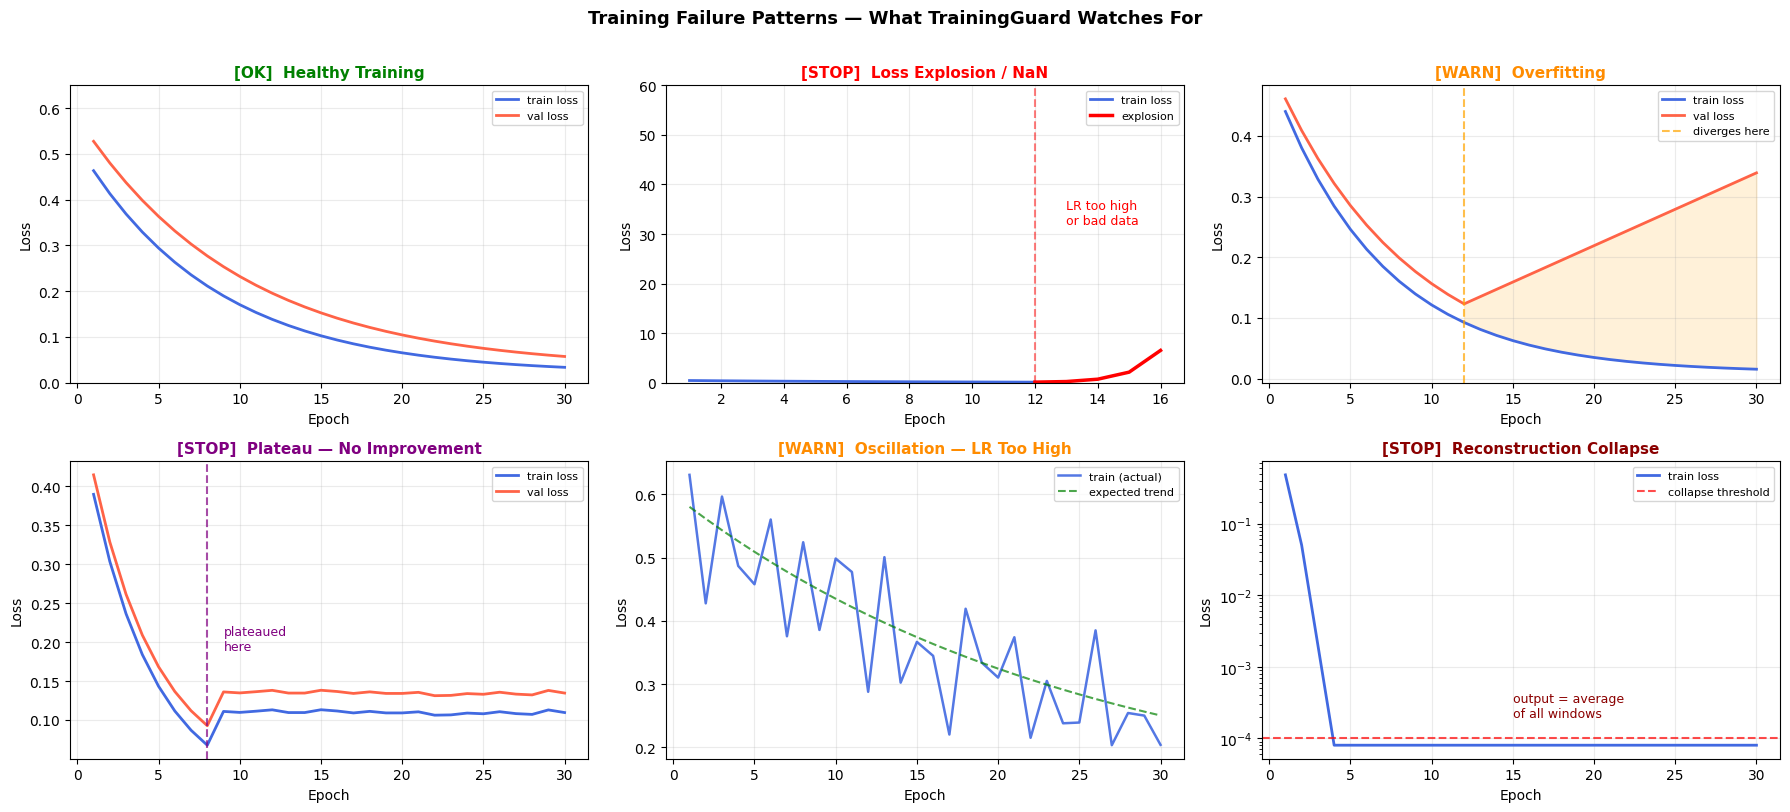

TrainingGuard ready.
  patience=7  |  min_delta=1e-05  |  overfit_ratio=2.5x  |  explosion=10.0x


In [15]:
# ── Diagnostic Illustrations ────────────────────────────────────────────────
np.random.seed(42)
e = np.arange(1, 31)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

# 1. Healthy
ax = axes[0]
tr = 0.5 * np.exp(-0.12 * e) + 0.02
vl = 0.55 * np.exp(-0.10 * e) + 0.03
ax.plot(e, tr, 'royalblue', lw=2, label='train loss')
ax.plot(e, vl, 'tomato',    lw=2, label='val loss')
ax.set_title('[OK]  Healthy Training', fontsize=11, color='green', fontweight='bold')
ax.set_ylim(0, 0.65); ax.legend(fontsize=8)

# 2. Loss Explosion
ax = axes[1]
tr_ok = 0.5 * np.exp(-0.12 * e[:12])
boom  = [tr_ok[-1] * f for f in [1, 2, 6, 18, 55]]
ax.plot(e[:12],   tr_ok, 'royalblue', lw=2,   label='train loss')
ax.plot(e[11:16], boom,  'red',       lw=2.5, label='explosion')
ax.axvline(12, color='red', ls='--', alpha=0.5)
ax.set_title('[STOP]  Loss Explosion / NaN', fontsize=11, color='red', fontweight='bold')
ax.set_ylim(0, 60); ax.legend(fontsize=8)
ax.annotate('LR too high\nor bad data', xy=(13, 32), fontsize=9, color='red')

# 3. Overfitting
ax = axes[2]
tr      = 0.5 * np.exp(-0.15 * e) + 0.01
base_vl = 0.52 * np.exp(-0.12 * 12)
vl      = np.concatenate([0.52 * np.exp(-0.12 * e[:12]),
                           base_vl + 0.012 * np.arange(1, 19)])
ax.plot(e, tr, 'royalblue', lw=2, label='train loss')
ax.plot(e, vl, 'tomato',    lw=2, label='val loss')
ax.axvline(12, color='orange', ls='--', alpha=0.7, label='diverges here')
ax.fill_between(e[11:], tr[11:], vl[11:], alpha=0.15, color='orange')
ax.set_title('[WARN]  Overfitting', fontsize=11, color='darkorange', fontweight='bold')
ax.legend(fontsize=8)

# 4. Plateau
ax = axes[3]
tr = np.concatenate([0.5 * np.exp(-0.25 * e[:8]),
                     np.full(22, 0.11) + 0.002 * np.random.randn(22)])
vl = tr + 0.025
ax.plot(e, tr, 'royalblue', lw=2, label='train loss')
ax.plot(e, vl, 'tomato',    lw=2, label='val loss')
ax.axvline(8, color='purple', ls='--', alpha=0.7)
ax.annotate('plateaued\nhere', xy=(9, 0.19), fontsize=9, color='purple')
ax.set_title('[STOP]  Plateau — No Improvement', fontsize=11, color='purple', fontweight='bold')
ax.legend(fontsize=8)

# 5. Oscillation
ax = axes[4]
base  = 0.5 * np.exp(-0.04 * e) + 0.1
noisy = base + 0.08 * np.sin(e * 2.5) + 0.04 * np.random.randn(30)
ax.plot(e, noisy, 'royalblue', lw=1.8, label='train (actual)', alpha=0.9)
ax.plot(e, base,  'g--',       lw=1.5, label='expected trend', alpha=0.7)
ax.set_title('[WARN]  Oscillation — LR Too High', fontsize=11, color='darkorange', fontweight='bold')
ax.legend(fontsize=8)

# 6. Reconstruction Collapse
ax = axes[5]
collapse = np.concatenate([[0.48, 0.05, 0.002], np.full(27, 8e-5)])
ax.plot(e, collapse, 'royalblue', lw=2, label='train loss')
ax.axhline(1e-4, color='red', ls='--', alpha=0.7, label='collapse threshold')
ax.set_yscale('log')
ax.set_title('[STOP]  Reconstruction Collapse', fontsize=11, color='darkred', fontweight='bold')
ax.legend(fontsize=8)
ax.annotate('output = average\nof all windows', xy=(15, 2e-4), fontsize=9, color='darkred')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.grid(alpha=0.25)

plt.suptitle('Training Failure Patterns — What TrainingGuard Watches For',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# ── TrainingGuard Class ──────────────────────────────────────────────────────
class TrainingGuard:
    """
    Monitors 6 training failure conditions each epoch.
    Call guard.check(epoch, train_loss, val_loss) — returns True to stop.
    Call guard.status(...) for a one-line health readout each epoch.
    """

    def __init__(
        self,
        patience: int           = 7,      # stop after N epochs of no val improvement
        min_delta: float        = 1e-5,   # improvement must exceed this to count
        overfit_ratio: float    = 2.5,    # val/train ratio that signals overfitting
        explosion_factor: float = 10.0,   # loss > initial × factor → explosion
        oscillation_window: int = 5,      # look-back window for oscillation check
        oscillation_cv: float   = 0.4,    # coefficient of variation threshold (40%)
        collapse_threshold: float = 1e-6, # loss below this → collapse
    ):
        self.patience           = patience
        self.min_delta          = min_delta
        self.overfit_ratio      = overfit_ratio
        self.explosion_factor   = explosion_factor
        self.oscillation_window = oscillation_window
        self.oscillation_cv     = oscillation_cv
        self.collapse_threshold = collapse_threshold

        self._best_val     = float("inf")
        self._no_improve   = 0
        self._initial_loss = None
        self._recent       = []
        self.stop_reason   = None

    def check(self, epoch: int, train_loss: float, val_loss: float) -> bool:
        if self._initial_loss is None:
            self._initial_loss = train_loss
        self._recent.append(train_loss)
        if len(self._recent) > self.oscillation_window:
            self._recent.pop(0)

        # 1. NaN / Inf ──────────────────────────────────────────────────────────
        # A bad batch drove weights to +-infinity. Training is mathematically broken.
        if not np.isfinite(train_loss) or not np.isfinite(val_loss):
            self.stop_reason = (
                f"[Epoch {epoch}] STOP: NaN/Inf loss  (train={train_loss}  val={val_loss})\n"
                "  Why:  gradients exploded — a bad batch drove weights to +-infinity.\n"
                "  Fix:  lower LR by 10x; add clip_grad_norm_(model.parameters(), 1.0);\n"
                "        check for zero-volume or extreme-outlier bars in the data."
            )
            return True

        # 2. Loss explosion ─────────────────────────────────────────────────────
        # Loss is growing instead of shrinking — model is actively diverging.
        if train_loss > self._initial_loss * self.explosion_factor:
            self.stop_reason = (
                f"[Epoch {epoch}] STOP: Loss exploded:  {train_loss:.5f} > "
                f"{self._initial_loss:.5f} x {self.explosion_factor}\n"
                "  Why:  LR too high — model overshoots the loss minimum every step.\n"
                f"  Fix:  set LR = {LR / 10:.1e} and restart from scratch."
            )
            return True

        # 3. Reconstruction collapse ────────────────────────────────────────────
        # Loss dropped to near-zero too fast. Decoder outputs the mean of all inputs —
        # low MSE, but the model learned nothing useful about market patterns.
        if train_loss < self.collapse_threshold:
            self.stop_reason = (
                f"[Epoch {epoch}] STOP: Reconstruction collapse:  loss = {train_loss:.2e} "
                f"< {self.collapse_threshold:.0e}\n"
                "  Why:  decoder outputs the average of all windows (trivial low-MSE solution).\n"
                "  Fix:  inspect reconstructions — they will all look identical.\n"
                "        Add input noise: x + 0.01 * torch.randn_like(x) to prevent this."
            )
            return True

        # 4. Overfitting ────────────────────────────────────────────────────────
        # Model memorised specific training windows instead of general patterns.
        if train_loss > 0 and (val_loss / train_loss) > self.overfit_ratio:
            self.stop_reason = (
                f"[Epoch {epoch}] WARN: Overfitting:  val/train = "
                f"{val_loss / train_loss:.2f} > {self.overfit_ratio}\n"
                f"  Why:  model memorised {WINDOW_SIZE}-bar windows, not general TSLA patterns.\n"
                f"  Fix:  add nn.Dropout(0.2) after encoder ReLUs;\n"
                f"        or reduce LATENT_DIM below {LATENT_DIM}."
            )
            return True

        # 5. No improvement (patience) ──────────────────────────────────────────
        # Val loss hasn't improved meaningfully in N epochs — model has converged.
        if val_loss < self._best_val - self.min_delta:
            self._best_val   = val_loss
            self._no_improve = 0
        else:
            self._no_improve += 1
            if self._no_improve >= self.patience:
                self.stop_reason = (
                    f"[Epoch {epoch}] STOP: Plateau:  no improvement for {self.patience} epochs "
                    f"(best val = {self._best_val:.5f})\n"
                    "  Why:  model has converged — more epochs won't help.\n"
                    "  Fix:  this is the normal, healthy outcome. Best weights are saved."
                )
                return True

        # 6. Oscillation ────────────────────────────────────────────────────────
        # Loss bounces up and down instead of smoothly declining.
        if len(self._recent) == self.oscillation_window:
            mean = np.mean(self._recent)
            std  = np.std(self._recent)
            cv   = std / mean if mean > 0 else 0.0
            if cv > self.oscillation_cv:
                self.stop_reason = (
                    f"[Epoch {epoch}] WARN: Oscillating:  CV = {cv:.2f} > {self.oscillation_cv}  "
                    f"(last {self.oscillation_window} epochs)\n"
                    f"  Recent losses: {[f'{l:.4f}' for l in self._recent]}\n"
                    "  Why:  LR too large — overshooting the minimum each epoch.\n"
                    f"  Fix:  set LR = {LR / 3:.1e} (divide by 3) and restart training."
                )
                return True

        return False

    def status(self, epoch: int, train_loss: float, val_loss: float) -> str:
        ratio  = val_loss / train_loss if train_loss > 0 else float("inf")
        filled = "#" * self._no_improve
        empty  = "-" * max(0, self.patience - self._no_improve)
        return (
            f"  Epoch {epoch:>4}/{EPOCHS}  |  "
            f"train={train_loss:.5f}  val={val_loss:.5f}  |  "
            f"overfit={ratio:.2f}x  |  patience [{filled}{empty}]"
        )


# Instantiate — tune these to your run
guard = TrainingGuard(
    patience          = 7,
    min_delta         = 1e-5,
    overfit_ratio     = 2.5,
    explosion_factor  = 10.0,
    oscillation_window= 5,
    oscillation_cv    = 0.4,
    collapse_threshold= 1e-6,
)
print("TrainingGuard ready.")
print(f"  patience={guard.patience}  |  min_delta={guard.min_delta}  |  "
      f"overfit_ratio={guard.overfit_ratio}x  |  explosion={guard.explosion_factor}x")

## 14. Train (Reconstruction Loss)

### The Optimizer and Learning Rate

```python
optimizer = torch.optim.Adam(model.parameters(), lr=LR)  # LR = 1e-3
```

**Adam** (Adaptive Moment Estimation) is the standard first choice for autoencoders. Unlike plain SGD — which applies the same step size to every weight — Adam adapts the step size *per weight* based on how consistently that weight has been moving. Weights that haven't changed much get larger steps; weights that are already oscillating get smaller ones. `LR` sets the baseline scale for all those individual adjustments.

---

### Do you need a chart for learning rate?

With a **fixed `LR = 1e-3`** (what we're using here) — **no**. It's a single constant for the entire run; there's nothing to plot.

A chart becomes useful only when you add a **learning rate scheduler** — code that adjusts `LR` automatically during training in response to what's happening:

| Scheduler | What it does | When to use |
|-----------|-------------|-------------|
| `ReduceLROnPlateau` | Halves `LR` when val loss stops improving for N epochs | Best default — automatic and safe |
| `CosineAnnealingLR` | Smoothly decays `LR` from start value down to near zero | Longer runs with a fixed epoch budget |
| `OneCycleLR` | Warms `LR` up then decays it (super-convergence) | When you need faster convergence in fewer epochs |

If you add a scheduler, you'd log `optimizer.param_groups[0]['lr']` each epoch and plot it on a second y-axis alongside `train_loss` and `val_loss`. For now, `LR = 1e-3` is fixed — the **Reconstruction Loss chart below tells you everything you need**.

In [ ]:
import os
from tqdm import tqdm

torch.set_num_threads(os.cpu_count())
print(f"PyTorch using {torch.get_num_threads()} threads")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
guard.stop_reason = None   # reset so cell is safe to re-run

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(b.to(DEVICE)), b.to(DEVICE)).item()
                       for b in test_loader) / len(test_loader)
    val_losses.append(val_loss)

    print(guard.status(epoch, train_losses[-1], val_loss))

    if guard.check(epoch, train_losses[-1], val_loss):
        print(f"\n{guard.stop_reason}")
        break
else:
    print(f"\nCompleted all {EPOCHS} epochs.")

plt.figure(figsize=(10, 3))
plt.plot(train_losses, label="train")
plt.plot(val_losses,   label="val")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Reconstruction Loss")
plt.tight_layout(); plt.show()

PyTorch using 4 threads


  Epoch    1/200  |  train=1.19933  val=0.99094  |  overfit=0.83x  |  patience [-------]


  Epoch    2/200  |  train=1.03748  val=0.94938  |  overfit=0.92x  |  patience [-------]


  Epoch    3/200  |  train=0.98099  val=0.90474  |  overfit=0.92x  |  patience [-------]


  Epoch    4/200  |  train=0.93270  val=0.86856  |  overfit=0.93x  |  patience [-------]


...

  Epoch    6/200  |  train=0.88518  val=0.83591  |  overfit=0.94x  |  patience [-------]


  Epoch    7/200  |  train=0.86194  val=0.82822  |  overfit=0.96x  |  patience [-------]


  Epoch    8/200  |  train=0.84704  val=0.81645  |  overfit=0.96x  |  patience [-------]


  Epoch    9/200  |  train=0.83892  val=0.82215  |  overfit=0.98x  |  patience [-------]


Epoch 10/200:  13%|▏| 62/490 [00:08<00:51

## 15. Extract Latent Vectors
Run every clean window through the encoder to get its compressed representation.

In [ ]:
all_loader = DataLoader(WindowDataset(
    torch.tensor(X_clean).permute(0, 2, 1)
), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
Z_list = []
with torch.no_grad():
    for batch in all_loader:
        Z_list.append(model.encoder(batch.to(DEVICE)).cpu().numpy())

Z = np.concatenate(Z_list)   # (N_clean, LATENT_DIM)
print(f"Latent matrix Z: {Z.shape}")

## 16. Cluster & Visualise Patterns
K-Means groups windows by latent similarity. t-SNE projects the 32-dimensional latent space to 2D so we can see the clusters. Cluster centroid plots reveal what each discovered pattern looks like.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# --- K-Means clustering ---
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z)
print("Cluster sizes:", dict(zip(*np.unique(labels, return_counts=True))))

# --- t-SNE on a subsample (full dataset is too large for t-SNE) ---
TSNE_SAMPLE = 10_000
idx = np.random.choice(len(Z), size=min(TSNE_SAMPLE, len(Z)), replace=False)
Z_2d = TSNE(n_components=2, random_state=42, perplexity=50).fit_transform(Z[idx])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=labels[idx],
                      cmap="tab10", s=3, alpha=0.6)
plt.colorbar(scatter, label="Cluster")
plt.title(f"t-SNE of Latent Space ({TSNE_SAMPLE:,} sample) — {N_CLUSTERS} clusters")
plt.tight_layout(); plt.show()

In [ ]:
# --- Cluster centroid patterns (full-width, stacked) ---
PLOT_FEATURES = ["close", "ema_9", "macd", "volume_ratio"]
plot_idx = [feature_cols.index(f) for f in PLOT_FEATURES]

for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    centroid_windows = X_clean[mask][:, :, plot_idx]   # (n_in_cluster, WINDOW_SIZE, 4)
    mean_window = centroid_windows.mean(axis=0)        # (WINDOW_SIZE, 4)

    fig, ax = plt.subplots(figsize=(18, 3))
    for i, fname in enumerate(PLOT_FEATURES):
        ax.plot(mean_window[:, i], label=fname, alpha=0.85)
    ax.set_title(f"Cluster {cluster_id}  (n={mask.sum():,})", fontsize=13)
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Bar (minutes)")
    plt.tight_layout()
    plt.show()

In [ ]:
from IPython.display import display, Markdown

_feature_descriptions = {
    "close":        "where {sym}'s price was, scaled so 0 = the median price over the whole dataset",
    "ema_9":        "a smoothed version of {sym}'s price over the last 9 minutes (reacts fast to moves)",
    "ema_21":       "a smoothed version of {sym}'s price over the last 21 minutes (slower trend)",
    "ema_50":       "a smoothed version of {sym}'s price over the last 50 minutes (longer-term trend)",
    "macd":         "momentum — positive = {sym} has been rising, negative = falling",
    "macd_9":       "signal line: a 9-period EMA of macd; crossovers are a classic buy/sell signal",
    "macd_hist":    "distance between macd and its signal line — growing = momentum is building",
    "volume_ratio": "how busy {sym} trading was compared to the 20-minute average (1.0 = normal)",
    "body":         "size and direction of the candle body (positive = bullish close, negative = bearish)",
    "upper_wick":   "how far price reached above the open/close during the bar",
    "lower_wick":   "how far price reached below the open/close during the bar",
    "return":       "percentage price change bar-over-bar",
    "vol_return":   "percentage volume change bar-over-bar",
    "log_return":   "log-scale price change — better for statistical analysis than raw returns",
}

_feature_lines = "\n".join(
    f"- **{f}** — {_feature_descriptions.get(f, f).format(sym=SYMBOL)}"
    for f in PLOT_FEATURES
)

_date_min = df["timestamp"].min().strftime("%b %Y")
_date_max = df["timestamp"].max().strftime("%b %Y")
_n_bars   = len(df)
_n_raw    = X_raw.shape[0]
_n_clean  = X_clean.shape[0]
_n_removed = _n_raw - _n_clean

display(Markdown(f"""
## 17. What You're Seeing

### The t-SNE Scatter Plot
Your {SYMBOL} 1-minute dataset spans {_date_min} to {_date_max} — that's **{_n_bars:,} bars**.
After slicing into overlapping {WINDOW_SIZE}-bar ({WINDOW_SIZE}-minute) windows, you have **{_n_raw:,} raw windows**.
Removing the **{_n_removed:,}** that straddle an overnight or weekend gap leaves **{_n_clean:,} clean windows**.

The autoencoder watched every one of those {SYMBOL} windows and gave each one a "fingerprint" —
{LATENT_DIM} numbers that summarise what was happening in those {WINDOW_SIZE} minutes of trading.

The problem is: {LATENT_DIM} numbers are impossible to visualise. So **t-SNE** squashes those {LATENT_DIM} numbers
down to just 2 (an x and y position on the chart) while trying to keep similar fingerprints close together.

**What the dots mean:**
- Each dot = one {WINDOW_SIZE}-minute window of {SYMBOL} trading
- Dots that are close together = windows that *felt* similar to the model
- The colour = which group (cluster) K-Means assigned it to

**What to look for:**
- Tight, well-separated blobs of colour = the model found genuinely distinct {SYMBOL} market behaviours
- A big smeared mess with no structure = the model hasn't learned much yet (try more epochs or a larger `LATENT_DIM` of {LATENT_DIM})

---

### The K-Means Clustering
K-Means is like a sorting machine. You told it: *"sort all {_n_clean:,} {SYMBOL} fingerprints into {N_CLUSTERS} piles"*
(`N_CLUSTERS = {N_CLUSTERS}`). It doesn't know anything about finance — it just puts fingerprints that are
numerically similar into the same pile.

Each pile = a **pattern type** the autoencoder found hiding in your {SYMBOL} data.
You chose {N_CLUSTERS}, but there's nothing magic about that number — try fewer or more and see if
the cluster centroid plots look more or less distinct.

---

### The Cluster Centroid Plots
These answer: *"What does a typical {SYMBOL} window in each cluster actually look like?"*

For each of the {N_CLUSTERS} clusters, we average together every {SYMBOL} window in that group and plot the result.
Think of it like averaging many photos of faces — the blurry average still shows you the general shape.

**What each line means:**
{_feature_lines}

**Example patterns you might see in {SYMBOL}:**
- A cluster where `close` and `ema_9` slope sharply upward → **strong uptrend**
- A cluster where `macd` crosses from negative to positive → **momentum reversal**
- A cluster where `volume_ratio` spikes while price is flat → **accumulation / distribution**
- A cluster where everything is flat and near zero → **dead/quiet market** (lunch hour, pre-market)

The model discovered these {N_CLUSTERS} groupings on its own — you never told it what a "trend" or "reversal" is.
"""))